In [1]:
import rioxarray
import geopandas as gpd
import pandas as pd

In [2]:
import os
import glob
from collections import defaultdict
import re
import rasterio
from rasterio.transform import Affine
from rasterio.windows import Window
from rasterio.transform import rowcol
import rioxarray
import xarray as xr
import numpy as np
import pdb
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from skimage.filters import threshold_otsu
from skimage.filters import threshold_multiotsu

In [3]:
gdf_old = gpd.read_file("D:/MyDrive/Stability/stability_masks_reprojected_WGS84.gpkg")
gdf_new = gpd.read_file("D:/MyDrive/Stability/bfast_correct_vector_reproj_WGS84.gpkg")
#gdf_new = gpd.read_file("D:/MyDrive/Ice_Stability_zones/bottomfast/bottomfast_beaufort/beaufort_bottomfast_repro.gpkg")
gdf_old = gdf_old[gdf_old.DN != 1]
gdf_new = gdf_new[gdf_new.DN == 1]
#gdf_new = gdf_new[gdf_new.OBJECTID == 1]
#gdf_new["DN"] = 1.0
gdf_updated = gpd.GeoDataFrame(pd.concat([gdf_old, gdf_new], ignore_index=True), crs=gdf_old.crs)

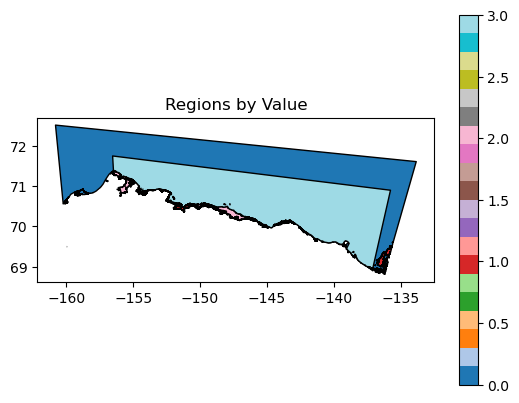

In [4]:
gdf_updated.plot(column='DN', cmap='tab20', legend=True, edgecolor='black')
plt.title("Regions by Value")
plt.show()

In [5]:
raster = rioxarray.open_rasterio("D:/MyDrive/Stability/RawData/Monthly_Averages/Masked/Beaufort/APR.tif", masked=True).squeeze()
#raster = rioxarray.open_rasterio("D:/MyDrive/Stability/RawData/Monthly_Averages/Beaufort/WeightedMeans_Union/WeightedMean_04.tif", masked=True).squeeze()

In [6]:
raster

<xarray.DataArray (y: 3297, x: 19135)> Size: 252MB
[63088095 values with dtype=float32]
Coordinates:
    band         int64 8B 1
  * x            (x) float64 153kB -177.8 -177.8 -177.8 ... -133.8 -133.8 -133.8
  * y            (y) float64 26kB 72.62 72.62 72.61 72.61 ... 65.05 65.05 65.04
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_APPROXIMATE:    YES
    STATISTICS_MAXIMUM:        6.0594677051995e-05
    STATISTICS_MEAN:           -8015.4713402543
    STATISTICS_MINIMUM:        -9999
    STATISTICS_STDDEV:         3987.3446257734
    STATISTICS_VALID_PERCENT:  8.35
    scale_factor:              1.0
    add_offset:                0.0

In [7]:
raster = raster.where(raster != -9999)

In [8]:
gdf_updated['DN'].unique()

array([0, 2, 3, 1], dtype=int32)

In [9]:
gdf_updated = gdf_updated.to_crs(raster.rio.crs)

# Get unique DN values
dn_values = gdf_updated['DN'].unique()

masked_rasters = {}

for dn in dn_values:
    # Select polygons for this DN
    gdf_dn = gdf_updated[gdf_updated['DN'] == dn]

    # Clip/mask raster by these polygons
    masked = raster.rio.clip(gdf_dn.geometry, gdf_dn.crs, drop=False)

    # Store in dict
    masked_rasters[dn] = masked
    print(f"Masked raster for DN={dn} created")

# Example: access masked raster for DN=1
masked_dn1 = masked_rasters[1]

Masked raster for DN=0 created
Masked raster for DN=2 created


C:\Users\aeinhorn\AppData\Local\anaconda3\envs\ksa206_environment\lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'Polygon', 'coordinates': ()} at index 1 will not be rasterized.
  warnings.warn(
C:\Users\aeinhorn\AppData\Local\anaconda3\envs\ksa206_environment\lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape {'type': 'Polygon', 'coordinates': ()} at index 3 will not be rasterized.
  warnings.warn(


Masked raster for DN=3 created
Masked raster for DN=1 created


<Figure size 1000x600 with 0 Axes>

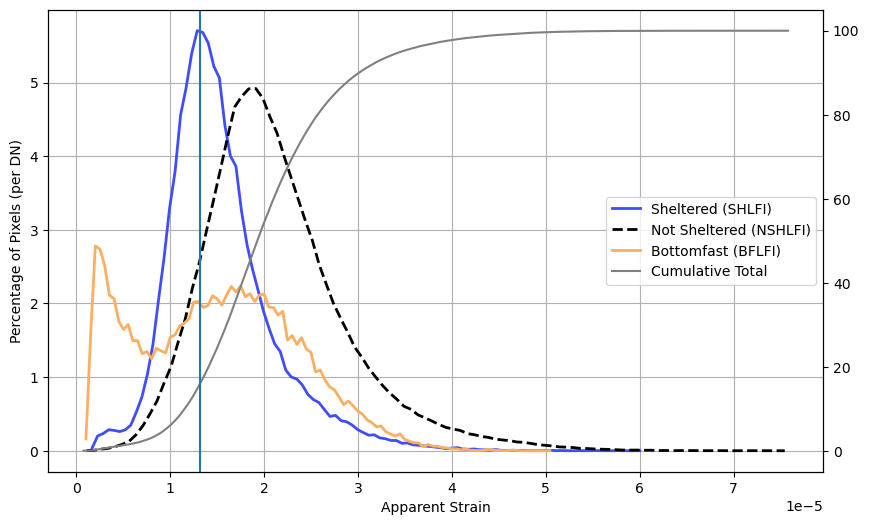

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

# Create main axis
fig, ax1 = plt.subplots(figsize=(10, 6))

all_values = []

# Define colors for DN
colors = {1: "#fdae61", 2: "#3f4cff", 3: "black"}

# Plot per-DN percentage histograms
for dn, masked in masked_rasters.items():
    if dn == 0:
        continue

    values = masked.values.flatten()
    values = values[~np.isnan(values)]
    all_values.extend(values)

    # Histogram for each DN (percent of DN)
    counts, bin_edges = np.histogram(values, bins=100)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    counts_percent = counts / counts.sum() * 100

    if dn == 1:
        ax1.plot(bin_centers, counts_percent, color=colors[dn], label="Bottomfast (BFLFI)", linewidth=2)
    elif dn == 2: 
        ax1.plot(bin_centers, counts_percent, color=colors[dn], label="Sheltered (SHLFI)", linewidth=2)
    elif dn == 3:
        ax1.plot(bin_centers, counts_percent, color=colors[dn], linestyle="--", label="Not Sheltered (NSHLFI)", linewidth=2)

# Configure primary axis
ax1.set_xlabel("Apparent Strain")
ax1.set_ylabel("Percentage of Pixels (per DN)")
ax1.grid(True)

# Total cumulative histogram on secondary y-axis
ax2 = ax1.twinx()
"""
# Secondary axis for cumulative curves

ax2.set_ylabel("Cumulative Percentage (%)")

for dn, masked in masked_rasters.items():
    if dn == 0:
        continue

    # Flatten raster and remove NaNs
    values = masked.values.flatten()
    values = values[~np.isnan(values)]

    # Histogram
    counts, bin_edges = np.histogram(values, bins=100)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # Cumulative percentage
    cum_percent = np.cumsum(counts) / counts.sum() * 100

    # Plot on secondary axis
    if dn == 1:
        ax2.plot(bin_centers, cum_percent, color=colors[dn], label="Bottomfast (BFLFI)")
    elif dn == 2:
        ax2.plot(bin_centers, cum_percent, color=colors[dn], label="Sheltered (SHLFI)")
    elif dn == 3:
        ax2.plot(bin_centers, cum_percent, color=colors[dn], linestyle="--", label="Not Sheltered (NSHLFI)")

#combine legends from both axes (here only ax2 has lines)
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines2, labels2, loc="right")
"""
all_values = np.array(all_values)
counts_total, bin_edges_total = np.histogram(all_values, bins=1000)
cum_counts_percent = np.cumsum(counts_total) / counts_total.sum() * 100
bin_centers_total = (bin_edges_total[:-1] + bin_edges_total[1:]) / 2

ax2.plot(bin_centers_total, cum_counts_percent, color="grey", linestyle="-", label="Cumulative Total")

plt.axvline(1.3188633602112532e-05)
# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="right")

plt.show()

In [11]:
all_values = raster.values.flatten()
all_values = all_values[~np.isnan(all_values)]

# Apply multi-Otsu with 3 classes → 2 thresholds
thresholds = threshold_multiotsu(all_values, classes=3)


In [12]:
thresholds

array([1.6196129e-05, 2.6894486e-05], dtype=float32)

In [13]:
thresholds_all = {}

for dn, masked in masked_rasters.items():
    if dn == 0:
        continue

    values = masked.values.flatten()
    values = values[~np.isnan(values)]

    if dn == 1:
        lower_threshold = np.percentile(values, 55)
        subset_values = values[values <= lower_threshold]
        thresh = threshold_otsu(subset_values)
        print(lower_threshold)
        print(f"for {dn} {thresh}")
    else:
        thresh = threshold_otsu(values)
        print(f"for {dn} {thresh}")

    # Store all thresholds in dictionary
    thresholds_all[dn] = thresh

for 2 1.785183121683076e-05
for 3 2.3753727873554453e-05
1.6348522e-05
for 1 8.603827154729515e-06


In [14]:
(2.3753727873554453e-05 +1.785183121683076e-05)/2

2.0802779545192607e-05

In [15]:
thresholds_all

{np.int32(2): np.float32(1.7851831e-05),
 np.int32(3): np.float32(2.3753728e-05),
 np.int32(1): np.float32(8.603827e-06)}

In [16]:
lower_threshold

np.float32(1.6348522e-05)

<Figure size 1000x600 with 0 Axes>

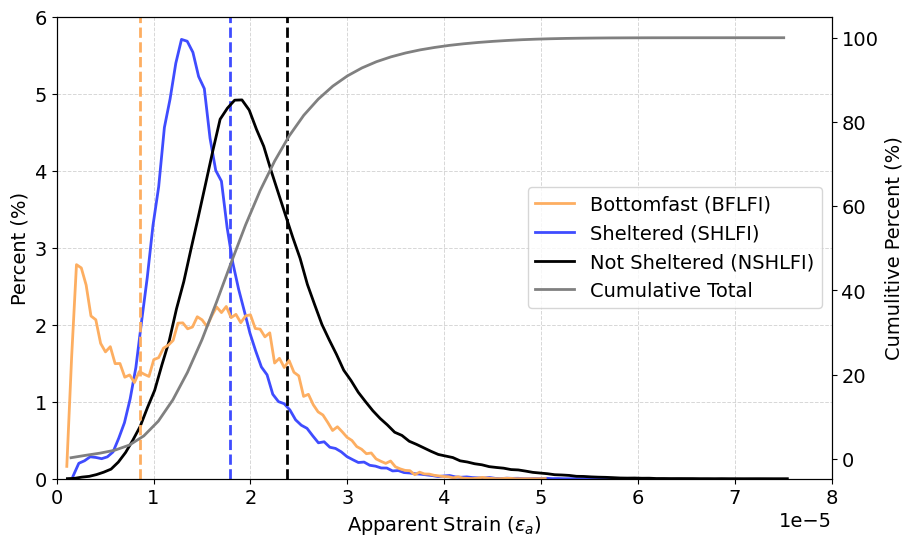

In [17]:
plt.figure(figsize=(10, 6))

# Create main axis
fig, ax1 = plt.subplots(figsize=(10, 6))

all_values = []

# Define colors for DN
colors = {1: "#fdae61", 2: "#3f4cff", 3: "black"}

# Plot per-DN percentage histograms
for dn, masked in masked_rasters.items():
    if dn == 0:
        continue

    values = masked.values.flatten()
    values = values[~np.isnan(values)]
    all_values.extend(values)

    # Histogram for each DN (percent of DN)
    counts, bin_edges = np.histogram(values, bins=100)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    counts_percent = counts / counts.sum() * 100

    if dn == 1:
        ax1.plot(bin_centers, counts_percent, color=colors[dn], label="Bottomfast (BFLFI)", linewidth=2)
    elif dn == 2: 
        ax1.plot(bin_centers, counts_percent, color=colors[dn], label="Sheltered (SHLFI)", linewidth=2)
    elif dn == 3:
        ax1.plot(bin_centers, counts_percent, color=colors[dn], linestyle="-", label="Not Sheltered (NSHLFI)", linewidth=2)

    # Only draw this DN’s threshold
    if dn in thresholds_all:
        ax1.axvline(
            thresholds_all[dn],
            color=colors[dn],
            linestyle="--",
            linewidth=2,
            label=f"Otsu Threshold {dn}"
        )

# Configure primary axis
ax1.set_xlabel("Apparent Strain")
ax1.set_ylabel("Percentage of Pixels (per Stability Zone)")
ax1.grid(True, which='major', linestyle='--', linewidth=0.7, alpha=0.5)

# Total cumulative histogram on secondary y-axis
ax2 = ax1.twinx()
all_values = np.array(all_values)
counts_total, bin_edges_total = np.histogram(all_values, bins=50)
cum_counts_percent = np.cumsum(counts_total) / counts_total.sum() * 100
bin_centers_total = (bin_edges_total[:-1] + bin_edges_total[1:]) / 2

ax2.plot(bin_centers_total, cum_counts_percent, color="grey", linestyle="-",linewidth=2, label="Cumulative Total")
ax2.set_ylabel("Cumulative Percentage (%)")
ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax1.set_xlim([0, 0.00008])
ax1.set_ylim([0, 6])
ax1.xaxis.get_offset_text().set_fontsize(14)
ax1.set_xlabel(r"Apparent Strain ($\epsilon_a$)",fontsize=14)
ax1.set_ylabel("Percent (%)",fontsize=14)
ax2.set_ylabel("Cumulitive Percent (%)",fontsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Merge
all_lines  = lines1 + lines2
all_labels = labels1 + labels2

# Define your desired order
# (add thresholds here if you gave them labels when plotting)
order = [
    "Bottomfast (BFLFI)",
    "Sheltered (SHLFI)",
    "Not Sheltered (NSHLFI)",
    "Cumulative Total",
    "Otsu Threshold BFLFI",
    "Otsu Threshold SHLFI",
    "Otsu Threshold NSHLFI"
]

# Reorder according to `order`
ordered_lines  = [all_lines[all_labels.index(o)] for o in order if o in all_labels]
ordered_labels = [o for o in order if o in all_labels]
#plt.axvline(lower_threshold,color='red')
# Apply legend
ax1.legend(ordered_lines, ordered_labels, loc="right", fontsize=14)

#plt.title("Distributions of Apparent Strain with Otsu Thresholds")
plt.show()
fig.savefig("D:/MyDrive/Stability/Figs/stability_distributions.png", dpi=300, bbox_inches="tight") 

Multi-Otsu thresholds (whole distribution): [1.6196129e-05 2.6894486e-05]


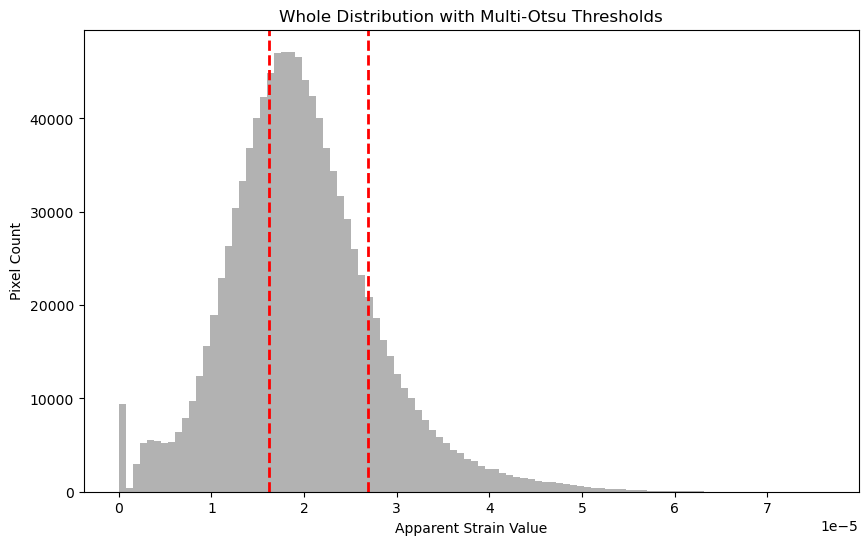

In [18]:
from skimage.filters import threshold_multiotsu
# Flatten the raster to 1D and remove NaNs
all_values = raster.values.flatten()
all_values = all_values[~np.isnan(all_values)]

# Apply multi-Otsu with 3 classes → 2 thresholds
thresholds = threshold_multiotsu(all_values, classes=3)

print("Multi-Otsu thresholds (whole distribution):", thresholds)

# Plot histogram of whole distribution
plt.figure(figsize=(10,6))
counts, bins, patches = plt.hist(all_values, bins=100, color="gray", alpha=0.6)

# Plot thresholds as vertical lines
for t in thresholds:
    plt.axvline(t, color="red", linestyle="--", linewidth=2)

plt.title("Whole Distribution with Multi-Otsu Thresholds")
plt.xlabel("Apparent Strain Value")
plt.ylabel("Pixel Count")
plt.show()